In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd


# Analysis of Variance (ANOVA): One Factor
## Example: Evaluating Battery Suppliers


You're working as an analyst for a consumer electronics company that sources batteries from multiple suppliers. To decide which supplier to enter into a long-term contract with, your team conducts a quality evaluation study. Specifically, you're interested in the **average battery life** provided by each supplier.

You select **three suppliers** and randomly test **seven batteries** from each. The table below shows the recorded battery life (in hours) for each sample:

In [3]:
# Create the battery life data
battery_data = pd.DataFrame({
    "Supplier A": [10.25, 9.93, 10.32, 9.76, 8.96, 9.08, 10.52],
    "Supplier B": [8.88, 8.27, 9.57, 8.27, 10.27, 8.68, 8.89],
    "Supplier C": [9.34, 9.92, 9.69, 10.36, 9.75, 10.65, 10.28]
})
# Print without row numbers
print(battery_data.to_string(index=False))

 Supplier A  Supplier B  Supplier C
      10.25        8.88        9.34
       9.93        8.27        9.92
      10.32        9.57        9.69
       9.76        8.27       10.36
       8.96       10.27        9.75
       9.08        8.68       10.65
      10.52        8.89       10.28




Naturally, all sample means are different, but this could be due to random variation. Since there are other factors to consider when choosing the supplier, you want to make sure that the differences you observe are indicative of a real difference of suppliers' quality.

It may be tempting to compare each pair of suppliers using **z-tests** or **t-tests** to look for significant differences in mean defect rates. However, this approach leads to a serious problem: the more tests you perform, the more likely you are to find a “statistically significant” result just by chance. 

***Quiz Question***
*If the probability of making a Type I error (false positive) is 5% when comparing two group means, what is the probability of making at least one Type I error if you perform three independent separate comparisons*?



This issue, known as **Type I error inflation**, can result in **false positives** — concluding that suppliers differ when they actually don’t.

To illustrate this, here’s a humorous take from [XKCD](https://xkcd.com/882/) on the dangers of unchecked multiple testing.



## One-Way ANOVA: formulating the hypothesis
In a nutshell, we want to distinguish between the situations like this, when all the observations come from the same distribution with a true mean $\mu$:

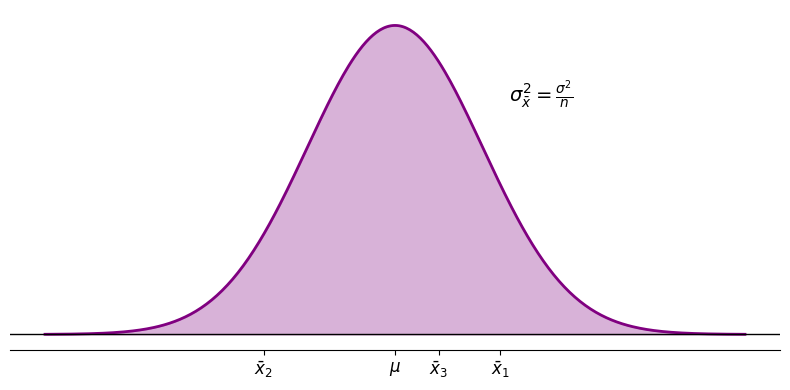

In [7]:
# Create the x values and normal distribution
mu = 0
sigma = 1
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
y = (1 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-(x - mu)**2 / (2 * sigma**2))

# Plot the normal distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, y, color='purple', linewidth=2)
ax.fill_between(x, y, color='purple', alpha=0.3)

# Custom ticks for x-axis
x_positions = [-1.5, 0, 0.5, 1.2]
x_labels = [r'$\bar{x}_2$', r'$\mu$', r'$\bar{x}_3$', r'$\bar{x}_1$']
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, fontsize=12)

# Add the variance formula as text
ax.text(1.3, 0.3, r'$\sigma_{\bar{x}}^2 = \frac{\sigma^2}{n}$', fontsize=14)

# Clean up axes
ax.set_yticks([])
ax.axhline(0, color='black', linewidth=1)
ax.spines[['right', 'left', 'top']].set_visible(False)

plt.tight_layout()
plt.show()

and this, where all the samples come from different distributions:

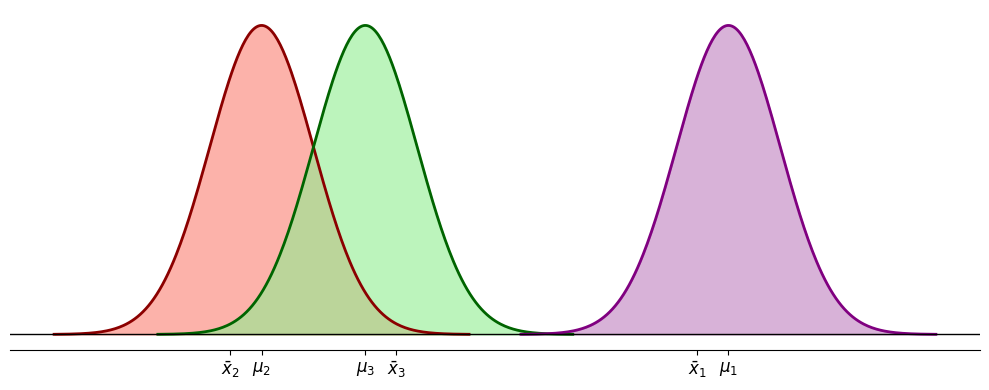

In [9]:
# Define means
mu2, mu3, mu1 = -3, -1, 6

# Generate x-values for each group
x_left = np.linspace(mu2 - 4, mu2 + 4, 300)   # Group 2 (left)
x_middle = np.linspace(mu3 - 4, mu3 + 4, 300) # Group 3 (middle)
x_right = np.linspace(mu1 - 4, mu1 + 4, 300)  # Group 1 (right)

# Compute y-values using normal PDF
y2 = (1 / np.sqrt(2 * np.pi)) * np.exp(-(x_left - mu2)**2 / 2)
y3 = (1 / np.sqrt(2 * np.pi)) * np.exp(-(x_middle - mu3)**2 / 2)
y1 = (1 / np.sqrt(2 * np.pi)) * np.exp(-(x_right - mu1)**2 / 2)

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x_left, y2, color='darkred', linewidth=2)
ax.fill_between(x_left, y2, color='salmon', alpha=0.6)

ax.plot(x_middle, y3, color='darkgreen', linewidth=2)
ax.fill_between(x_middle, y3, color='lightgreen', alpha=0.6)

ax.plot(x_right, y1, color='purple', linewidth=2)
ax.fill_between(x_right, y1, color='purple', alpha=0.3)

# Add x-axis ticks and labels for sample and population means
ax.set_xticks([mu2 - 0.6, mu2, mu3, mu3 + 0.6, mu1 - 0.6, mu1])
ax.set_xticklabels([r'$\bar{x}_2$', r'$\mu_2$', r'$\mu_3$', r'$\bar{x}_3$', r'$\bar{x}_1$', r'$\mu_1$'], fontsize=12)

# Style cleanup
ax.set_yticks([])
ax.axhline(0, color='black', linewidth=1)
for spine in ['right', 'left', 'top']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

or this, where some of the samples are coming from the same distribution, but others are not:

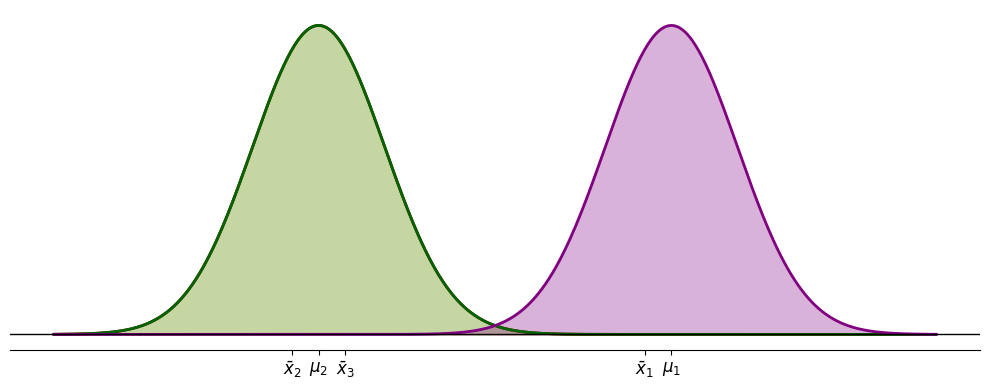

In [11]:

# Define parameters
mu_2 = -2  # Mean for left two groups
mu_1 = 6   # Mean for right group
sigma = 1.5  # Higher standard deviation for overlap


# Extend the x range to show more overlap between the distributions
x_extended = np.linspace(-8, 12, 500)

# Recalculate distributions with extended x-range and high variance
y_left_1_ext = (1 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-(x_extended - mu_2)**2 / (2 * sigma**2))
y_left_2_ext = y_left_1_ext  # Same as left_1
y_right_ext = (1 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-(x_extended - mu_1)**2 / (2 * sigma**2))

# Plotting
fig, ax = plt.subplots(figsize=(10, 4))

# Plot left group 1
ax.plot(x_extended, y_left_1_ext, color='darkred', linewidth=2)
ax.fill_between(x_extended, y_left_1_ext, color='salmon', alpha=0.5)

# Plot left group 2
ax.plot(x_extended, y_left_2_ext, color='darkgreen', linewidth=2)
ax.fill_between(x_extended, y_left_2_ext, color='lightgreen', alpha=0.5)

# Plot right group
ax.plot(x_extended, y_right_ext, color='purple', linewidth=2)
ax.fill_between(x_extended, y_right_ext, color='purple', alpha=0.3)

# X-axis labels
ax.set_xticks([mu_2 - 0.6, mu_2, mu_2 + 0.6, mu_1 - 0.6, mu_1])
ax.set_xticklabels([r'$\bar{x}_2$', r'$\mu_2$', r'$\bar{x}_3$', r'$\bar{x}_1$', r'$\mu_1$'], fontsize=12)

# Clean up
ax.set_yticks([])
ax.axhline(0, color='black', linewidth=1)
for spine in ['right', 'left', 'top']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

Formally,

$H_0: \mu_1 = \mu_2 = ... = \mu_k$

$H_A: \mu_i \neq \mu_j$ for some $i, j \in \overline{1, k}$

Looking ahead, ANOVA test will give us the following output:

In [14]:
f_stat, p_value = stats.f_oneway(battery_data["Supplier A"],
                           battery_data["Supplier B"],
                           battery_data["Supplier C"])

print("F-statistic = ", round(f_stat, 4), "p-value = ", round(p_value, 4))

F-statistic =  5.7596 p-value =  0.0117


As you already know, we make the conclusion based on our p-value. Here, if we use $\alpha = 0.05$, we reject the null hypothesis and conclude that at least one supplier's batteries have mean battery life that is different from the others. In other words, there exists a statistically significant relationship between the qualitative variable "Supplier" and the quantitative varable "Battery Life".

## ANOVA Assumptions

Analysis of Variance technique (ANOVA) is used to study the relationship between a quantitative variable and one or more quantitative variables.

- **Response variable**, often referred as **dependent variable (DV)** is a variable of interest that a researcher is trying to explain or predict using one or more **explanatory variables**, aka **independent variables**.
  - Example: Batery life is a response variable in our battery life study.
- **Factor** is a qualitative **explanatory variable**.
    - Example: Supplier is a factor in our battery life study.




In [17]:
# Convert to long format
df_long = battery_data.melt(var_name='Supplier', value_name='BatteryLife')
print(df_long)


      Supplier  BatteryLife
0   Supplier A        10.25
1   Supplier A         9.93
2   Supplier A        10.32
3   Supplier A         9.76
4   Supplier A         8.96
5   Supplier A         9.08
6   Supplier A        10.52
7   Supplier B         8.88
8   Supplier B         8.27
9   Supplier B         9.57
10  Supplier B         8.27
11  Supplier B        10.27
12  Supplier B         8.68
13  Supplier B         8.89
14  Supplier C         9.34
15  Supplier C         9.92
16  Supplier C         9.69
17  Supplier C        10.36
18  Supplier C         9.75
19  Supplier C        10.65
20  Supplier C        10.28


ANOVA results are valid under the following assumptions:


#### 1. Independence of Observations
- Observations must be **independent** within and between groups.
    - this is typically ensured through **random sampling** or **random assignment**.


#### 2. Normality
- The **response variable** should be approximately **normally distributed within each group**.
- Can be assessed using:
  - Histograms
  - Q-Q plots
  - Shapiro-Wilk test

ANOVA is robust to moderate violations of normality if sample sizes are equal and large.


#### 3. Homogeneity of Variance (Homoscedasticity)
- The **variances across groups** should be **roughly equal**.
- Can be assessed using:
  - Levene’s Test
  - Bartlett’s Test
  - Side-by-side box plots


If these assumptions are violated, consider:
- Transforming the response variable (e.g., log or square root)
- Using **Welch’s ANOVA** (for unequal variances)
- Switching to a **non-parametric alternative** (e.g., Kruskal-Wallis test)
These methods are outside of the scope of this course.

Let's look at our battery suppliers data:


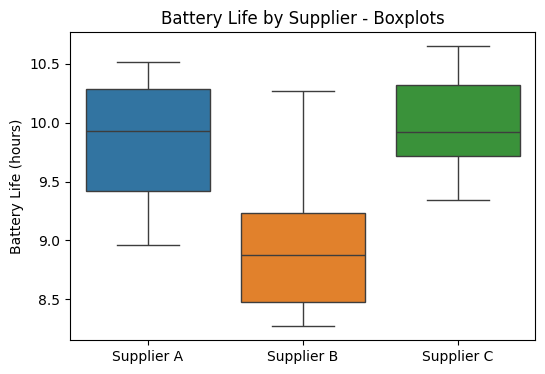

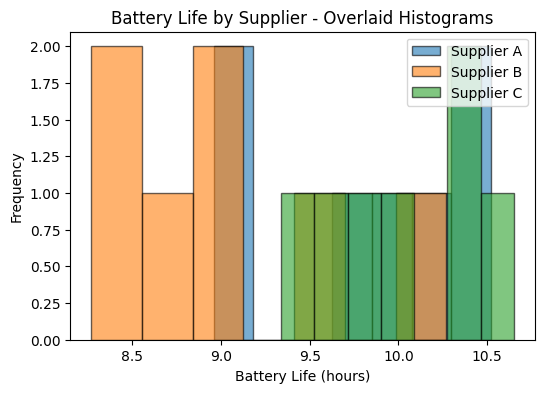

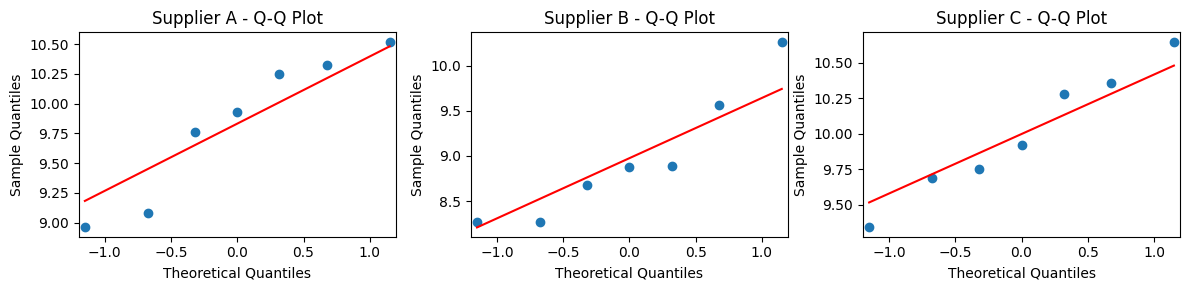

In [66]:
# Side-by-side boxplots
plt.figure(figsize=(6, 4))
sns.boxplot(data=battery_data)
plt.title("Battery Life by Supplier - Boxplots")
plt.ylabel("Battery Life (hours)")
plt.show()

# Overlaid histograms
plt.figure(figsize=(6, 4))
for supplier, color in zip(battery_data.columns, ['skyblue', 'salmon', 'lightgreen']):
    plt.hist(battery_data[supplier], bins=7, alpha=0.6, label=supplier, edgecolor='black')
plt.title("Battery Life by Supplier - Overlaid Histograms")
plt.xlabel("Battery Life (hours)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# Q-Q plots
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, supplier in zip(axes, battery_data.columns):
    sm.qqplot(battery_data[supplier], line = 's', ax=ax)
    ax.set_title(f"{supplier} - Q-Q Plot")
plt.tight_layout()
plt.show()


Based on the visualizations, there appear to be no serious violations of ANOVA assumptions. The box plots suggest that variability across groups is similar, and there are no extreme outliers. The Q-Q plots show that the sample quantiles closely follow the theoretical normal line, without obvious deviations or patterns. Taken together, this suggests that the results of the ANOVA can be considered reliable in this context.

## ANOVA step-by-step: Battery Suppliers

In ANOVA, we are comparing $k$ groups, each of size $n$. In the Battery Suppliers example, we have $k = 3$, and $n = 7$, The sample averages are $\bar{x}_A$, $\bar{x}_B$, and $\bar{x}_C$ are:



In [23]:
supplier_means = battery_data.mean()
print(supplier_means.round(2))

Supplier A     9.83
Supplier B     8.98
Supplier C    10.00
dtype: float64


We start by assuming that the null hypothesis is true, that is, 

$$
\mu = \mu_A = \mu_B = \mu_C
$$

If this is the case, and if the ANOVA assumptions are satisfied, then, according to the Central Limit Theorem, the sample means must be i.i.d. random variables following Normal distribution:

$$
\bar{x}_i \sim N(\mu, \frac{\sigma}{\sqrt{n}}),
$$

Where $\sigma$ is the standard deviation of the individual battery lives.

We find the estimate for the population mean $\mu$ by taking the average of all observations, $\bar{\bar{x}}$:

In [26]:
np.mean(battery_data)

9.60190476190476

Using the sample means, we find an estimate of the standard error as:

$$
s^2_{\bar{x}} = \frac{ (\bar{\bar{x}} - \bar{x}_1)^2 + ... + (\bar{\bar{x}} - \bar{x}_k)^2 }{k - 1} = \frac{(9.60 - 9.83)^2 + (9.60 - 8.98)^2 + (9.60 - 10)^2 }{3 - 1} \approx 0.301
$$


Since $s^2_{\bar{x}} = \frac{s^2}{n}$, then the estimate of $\sigma^2$ can be found as 

$$
s^2_{between} = n s^2_{\bar{x}} = 7 \times 0.301 = 2.107
$$

This value is referred to as the *between-groups* estimate of $\sigma^2$, or **Mean Square due to Treatments, MSTr**

In Python, you can calculate it as follows::

In [30]:
mstr = 7*np.var(supplier_means, ddof = 1)
print(mstr)

2.107490476190479


Now, if the null hypothesis is true, we can also obtain the estimate of $\sigma^2$ from each sample separately. That is,

$$
s^2_j = \frac{(x_{1j} - \bar{x}_j)^2 + (x_{2j} - \bar{x}_j)^2 + ... + (x_{nj} - \bar{x}_j)^2 }{n - 1}
$$

In [32]:
print(battery_data.var(ddof = 1))
mse = np.mean(battery_data.var(ddof = 1))

Supplier A    0.371148
Supplier B    0.521395
Supplier C    0.205181
dtype: float64


Since the samples are of equail size, we can obtain a *pooled*, aka *within-groups* estimate of $\sigma^2$  by taking a simple average of those three values. We obtain $s^2_{within} = 0.366$. This estimate is also referred to as **Mean Square due to Error, MSE**

Intuitively, if the $H_0$ is true, the estimates $s^2_{between}$ (MSTr) and $s^2_{within}$ (MSE) should be fairly close to each other: that is, the difference is sample averages is explained by the variation $\sigma^2$. If $H_0$ is false, we would expect the observed between groups variation to be higher than within group variation, or, equivalently, $\frac{MSTr}{MSE} > 1$.

It turns out that under ANOVA assumptions the ratio $\frac{MSTr}{MSE}$ can be modeled via F-distribution, which is defined by the numerator degrees of freedom $df_1 = k-1 $ and the denominator degrees of freedom $df_2 = k(n - 1)$. In our example, $df_1 = 2$, $df_2 = 18$.

We find the test statistic as

$$
F = \frac{MSTr}{MSE} = \frac{2.107}{0.366} \approx 5.760
$$

We can use Python to find p-value as the right-tail area of F-distribution.


In [34]:

df_between = len(battery_data.columns) - 1
df_within = battery_data.size- len(battery_data.columns)
f_stat = mstr/mse
p_value = 1 - stats.f.cdf(f_stat, df_between, df_within)

print("F-statistic = MSTr/MSE = ", round(f_stat, 4))
print("p-value = ", round(p_value, 4))

F-statistic = MSTr/MSE =  5.7596
p-value =  0.0117


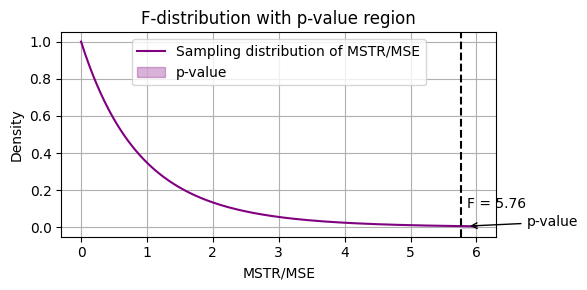

In [35]:
# Generate F-distribution


x = np.linspace(0, 6, 500)
y = stats.f.pdf(x, df_between, df_within)

# Plot the F-distribution
plt.figure(figsize=(6, 3))
plt.plot(x, y, label="Sampling distribution of MSTR/MSE", color='purple')
plt.fill_between(x, y, where=(x > f_stat), color='purple', alpha=0.3, label='p-value')

# Vertical line at F-statistic
plt.axvline(f_stat, color='black', linestyle='--')
plt.text(f_stat + 0.1, stats.f.pdf(f_stat, df_between, df_within)+0.1, f'F = {f_stat:.2f}')

# Annotate p-value
plt.annotate('p-value', xy=(f_stat + 0.1, stats.f.pdf(f_stat, df_between, df_within)),
             xytext=(f_stat + 1, stats.f.pdf(f_stat, df_between, df_within)),
             arrowprops=dict(facecolor='black', arrowstyle='->'))

# Axis labels and title
plt.xlabel("MSTR/MSE")
plt.ylabel("Density")
plt.title("F-distribution with p-value region")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## One-Way ANOVA: summary
In the example above all groups were of the same size. This is ideal, but not necessary. In general, the analysis goes as follows.

We assume that a simple random sample of size $n_j$ has been selected from each of the $k$ populations or treatments. For the resulting sample data, let:

$$
\begin{aligned}
\mu_j & = \text{mean of the } j\text{th population} \\
x_{ij} & = \text{value of observation } i \text{ for treatment } j \\
n_j & = \text{number of observations for treatment } j \\
n_T & = \text{total number of observations, } n_T = n_1 + n_2 + \dots + n_j \\
\bar{x}_j & = \text{sample mean for treatment } j \\
\bar{\bar{x}} & = \text{overall sample mean} \\
s_j^2 & = \text{sample variance for treatment } j \\
s_j & = \text{sample standard deviation for treatment } j
\end{aligned}
$$

We compute:


Sum of Squares due to Treatments
$$
SSTr =  \sum_{j = 1}^k n_j(\bar{\bar{x}} - \bar{x}_j)^2
$$

Mean of Squares due to Treatments
$$
MSTr = \frac{SSTr}{k - 1}
$$

$$
s^2_j = \frac{\sum_{i = 1}^{n_j}(x_{ij} - \bar{x}_j)^2 }{n_j - 1}
$$

Sum of Squares due to Error, aka Residual Sum of Squares:

$$
SSE = \sum_{j = 1}^k (n_j - 1)s_j^2
$$

Mean of Squares due to Error

$$
MSE = \frac{SSE}{n_T - k}
$$

Total Sum of Squares (SST)

$$
SST = SSTr + SSE = \sum_{j = 1}^k \sum_{i = 1}^{n_j} (\bar{\bar{x}} - x_{ij})^2
$$



F-statistic:
$$
F = \frac{MSTr}{MSE}
$$

The typical software output of ANOVA is a table like this:

### ANOVA Summary Table

| Source of Variation       | df       | SS     | MS       | F          | P-value   |
|---------------------------|----------|--------|----------|------------|-----------|
| Between Samples (Treatments) | $k - 1$ | SSTr   | MSTr     | MSTr / MSE | p-value   |
| Within Samples (Error)    | $n_T - k$ | SSE    | MSE      |            |           |
| Total Variation           | $n_T - 1$ | SST    |          |            |           |


## More on Python

Here is how we can run ANOVA using ols function from statsmodels package, which would also print SSTr and SSE.

In [38]:
# Run ANOVA using statsmodels

# Fit an ordinary least squares (OLS) model
# 'BatteryLife' is the response variable
# 'C(Supplier)' treats 'Supplier' as a categorical factor
# If you just wrote 'Supplier', it would be treated as numeric — which we don't want
model = ols('BatteryLife ~ C(Supplier)', data=df_long).fit()

# Perform ANOVA on the fitted model
# typ=2 specifies the type of sums of squares used in the analysis
# There are three common types:
#   Type I  (typ=1): Sequential sums of squares
#       - Each term is tested in the order it appears in the model
#       - Useful for balanced designs or hierarchical models
#
#   Type II (typ=2): Adjusted for all other terms (excluding interactions)
#       - Each main effect is tested after accounting for the others
#       - Recommended for models without interaction terms (especially with balanced designs)
#
#   Type III (typ=3): Adjusted for all other terms, including interactions
#       - Each term is tested in the presence of all other terms
#       - Often used with unbalanced designs or when interactions are included

anova_table = sm.stats.anova_lm(model, typ=2)

# Round the results to 4 decimal places for readability
anova_table.round(4)

,sum_sq,df,F,PR(>F)
C(Supplier),4.2150,2.0,5.7596,0.0117
Residual,6.5863,18.0,NaN,NaN


# Post-Hoc Analysis

## Fisher Least Significant Difference (LSD)

Now that we've determined there is a significant difference among group means, the next step is to identify which specific groups differ, and in what way. Now we can use t-tests for pairwise comparisons -- an approach we described at the beginning. Note that we can only do that when we established that some differences indeed exist. For each pair of groups $i, j$ we test:

$H_0: \mu_i = \mu_j$

$H_A: \mu_i \neq \mu_j$

We perform the test by computing a test statistic for each pair:

$$
t = \frac{\bar{x}_i - \bar{x}_j}{\sqrt{MSE \left (  \frac{1}{n_i} + \frac{1}{n_j} \right )}}
$$

And the t-distribution we use is based on $n_T - k$ degrees of freedom.

The primary difference from the **two-sample t-test** we studied earlier is that Fisher's LSD uses the **MSE (Mean Square Error)** — the variance estimate based on all groups from the ANOVA —- instead of using the pooled variance estimate from only the two compared groups. Consequently, the number of degrees of freedom in Fisher LSD is $n_T - k$ rather than $n_i + n_j - 2$.

The rejection rule is the same as for two-tailed t-test.

We can also describe the test as:

Reject $H_0$ if $ | \bar{x}_i - \bar{x}_j | > LSD$,

where $ LSD = t_{\frac{\alpha}{2}}\sqrt{MSE \left (  \frac{1}{n_i} + \frac{1}{n_j} \right )}$

For example, for the Supplier Selection data, $t_{\frac{\alpha}{2}}$ is based on 21 - 3 = 18 degrees of freedom. For $\alpha = 0.05$ we get:


In [40]:
alpha = 0.05
t_crit = stats.t.ppf(1 - alpha/2, df_within)
print("t_0.025 = ", round(t_crit, 3))

t_0.025 =  2.101


And since the sampe sizes are all equal, the Least Significant Difference is the same for all pairs in our example: $LSD = 2.101 \times \sqrt{0.366 \times \frac{2}{7}  } = 0.679$

Hence, we conclude that the difference exists between two suppliers whenever the difference in sample means is greater than 0.697 hours. In our example we conclude that the differences exist between supplier A vs. B and B vs. C, but as for A vs. C -- there is not enough evidence to say.

## Tukey's Honestly Significant Difference (HSD) procedure 

Fisher LSD does not make adjustments for multiple comparisons, and hence it is still subject for Type I error inflation. A more conservative procedure that makes that adjustment is Tukey's HSD. It is based on the largest observed difference in means, and the test statistic follows another distribution: Studentized Range Distribution. In Python, it can be run as follows:

In [43]:
tukey_results = pairwise_tukeyhsd(endog=df_long["BatteryLife"], groups=df_long["Supplier"])
tukey_results.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
Supplier A,Supplier B,-0.8557,0.0414,-1.6809,-0.0305,True
Supplier A,Supplier C,0.1671,0.8641,-0.6581,0.9923,False
Supplier B,Supplier C,1.0229,0.0142,0.1977,1.8481,True


Here we come to the same conclusions as with Fisher LSD: the differences exist between supplier A vs. B and B vs. C, but as for A vs. C -- there is not enough evidence to say.